In [2]:
import json
from pathlib import Path
from typing import Dict, List

from model_ranking import (
    load_transfer_metric_results,
    aug_name_to_sigma_tuple,
)

In [3]:
# Test the aug_name_to_sigma_tuple function
test_cases = [
    "a001-003", "a001-a003",  # Both formats for same values
    "a003-005", "a003-a005",
    "a005-007", "a007-01", "a01-02"
]

print("Testing aug_name_to_sigma_tuple function:")
for aug_name in test_cases:    
    sigma_tuple = aug_name_to_sigma_tuple(aug_name)
    print(f"{aug_name} -> {sigma_tuple}")

Testing aug_name_to_sigma_tuple function:
a001-003 -> (0.01, 0.03)
a001-a003 -> (0.01, 0.03)
a003-005 -> (0.03, 0.05)
a003-a005 -> (0.03, 0.05)
a005-007 -> (0.05, 0.07)
a007-01 -> (0.07, 0.1)
a01-02 -> (0.1, 0.2)


In [4]:
performance_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/transfer_performance_scores.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]


In [5]:
import matplotlib.pyplot as plt
from typing import Optional, Tuple
import numpy as np
from model_ranking.correlation import calculate_correlation_statistics

def plot_single_consistency_vs_performance(
    augmentation_strength: str,
    target_dataset: str,
    performance_path: str = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/transfer_performance_scores.json",
    base_consistency_path: str = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency",
    custom_legend_labels: Optional[Dict[str, str]] = None,
    figsize: Tuple[int, int] = (10, 8),
    alpha: float = 0.7,
    marker_size: int = 200,
    fontsize: int = 16,
    cmap: str = "tab20",
    perturbation_type: str = "Gauss",
    file_name_postfix: str = "CMB_05f_05b_EI_scores",
    source_abbreviations = ['E', "Hm", "Rm", "V"],
):
    """
    Plot consistency scores vs performance scores for a single augmentation strength and target dataset.
    
    Parameters:
    -----------
    augmentation_strength : str
        The augmentation strength identifier (e.g., "a001-a003")
    target_dataset : str
        The target dataset name (e.g., "EPFL", "Hmito", "Rmito", "VNC")
    performance_scores : Dict
        Dictionary containing performance scores organized as {target: {model: score}}
    base_consistency_path : str
        Base path to the consistency scores JSON files
    custom_legend_labels : Optional[Dict[str, str]]
        Optional mapping from model names to custom legend labels
    correlation_scores : Optional[Dict[str, float]]
        Optional dictionary with correlation scores, e.g., {"kt": 0.95, "sp": 0.12, "p": 0.67}
        where "kt" is Kendall tau, "sp" is Spearman's ρ, and "p" is Pearson r
    figsize : tuple
        Figure size (width, height)
    alpha : float
        Transparency of the markers
    marker_size : int
        Size of the scatter plot markers
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    
    # Load consistency scores for the specified augmentation
    file_name = f"transfer_{perturbation_type}_{augmentation_strength}_{file_name_postfix}.json"
    consistency_path = Path(base_consistency_path) / file_name
    results = load_transfer_metric_results(consistency_path)
    consistency_scores = results["transfer_scores"]

    performance_results = load_transfer_metric_results(performance_path)
    performance_scores = performance_results["performance_scores"]

    # Extract scores for the target dataset
    if target_dataset not in performance_scores:
        raise ValueError(f"Target dataset '{target_dataset}' not found in performance scores")
    if target_dataset not in consistency_scores:
        raise ValueError(f"Target dataset '{target_dataset}' not found in consistency scores")
    
    target_performance = performance_scores[target_dataset]
    target_consistency = consistency_scores[target_dataset]
    
    # Find common models between performance and consistency scores
    common_models: set[str] = set(target_performance.keys()) & set(target_consistency.keys())
    if not common_models:
        raise ValueError(f"No common models found between performance and consistency scores for target '{target_dataset}'")
    
    # Prepare data for plotting
    x_values: List[float] = []  # consistency scores
    y_values: List[float] = []  # performance scores
    labels: List[str] = []

    for model in sorted(common_models):
        x_values.append(target_consistency[model])
        y_values.append(target_performance[model])
        
        # Use custom label if provided, otherwise use model name
        if custom_legend_labels and model in custom_legend_labels:
            labels.append(custom_legend_labels[model])
        else:
            labels.append(model)
    
    consis_array = np.array(x_values).reshape(-1, 1)  # Shape (n_models, 1)
    kt_scores, sp_scores, pearson_scores = calculate_correlation_statistics(
        consis_array, np.array(y_values)
    )
    pr = pearson_scores[0, 0]  # Pearson r
    sp = sp_scores[0, 0]    # Spearman rho
    kt = kt_scores[0, 0]    # Kendall tau
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get the colormap
    colormap = plt.cm.get_cmap(cmap)
    
    # Create scatter plot with different colors for each model
    _ = ax.scatter(x_values, y_values, s=marker_size, alpha=alpha, c=range(len(labels)), cmap=cmap)
    
    sigmas = aug_name_to_sigma_tuple(augmentation_strength)
    # Add labels and title
    _ = ax.set_xlabel(f'Consistency Score', fontsize=fontsize)
    _ = ax.set_ylabel('Performance Score (F1)', fontsize=fontsize)
    _ = ax.set_title(f'Consistency vs Performance for {target_dataset}\n(Augmentation:  Gauss [{sigmas[0]}, {sigmas[1]}])', fontsize=fontsize)

    # Add legend with matching colors
    for i, label in enumerate(labels):
        # Use the same colormap normalization as the scatter plot
        color = colormap(i / (len(labels) - 1) if len(labels) > 1 else 0)
        _ = ax.scatter([], [], c=[color], s=marker_size, alpha=alpha, label=label)
    legend = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add correlation scores text if provided
    # Format correlation scores text
    corr_text = "Correlation Scores:\n"

    corr_text += f"Kendall τ: {kt:.2f}\n"

    corr_text += f"Spearman ρ: {sp:.2f}\n"

    corr_text += f"Pearson r: {pr:.2f}"

    # Position the text below the legend
    legend_bbox = legend.get_window_extent(fig.canvas.get_renderer())
    # Convert to figure coordinates
    legend_bottom = legend_bbox.y0 / fig.bbox.height
    
    # Add text box below the legend
    _ = ax.text(1.05, legend_bottom - 0.05, corr_text, 
            transform=ax.transAxes, fontsize=fontsize-2,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Add grid for better readability
    _ = ax.grid(True, alpha=0.8)

    # Tight layout to prevent legend cutoff
    plt.tight_layout()
    
    return fig, ax

In [9]:
import matplotlib.pyplot as plt
from typing import Optional, Tuple
import numpy as np
from model_ranking.correlation import calculate_correlation_statistics

def plot_single_consistency_vs_performance2(
    augmentation_strength: str,
    target_dataset: str,
    performance_path: str = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/transfer_performance_scores.json",
    base_consistency_path: str = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency",
    custom_legend_labels: Optional[Dict[str, str]] = None,
    figsize: Tuple[int, int] = (10, 8),
    alpha: float = 0.7,
    marker_size: int = 200,
    fontsize: int = 16,
    perturbation_type: str = "Gauss",
    file_name_postfix: str = "CMB_05f_05b_EI_scores",
    source_abbreviations = ['E', "Hm", "Rm", "V"],
):
    """
    Plot consistency scores vs performance scores for a single augmentation strength and target dataset.
    
    Parameters:
    -----------
    augmentation_strength : str
        The augmentation strength identifier (e.g., "a001-a003")
    target_dataset : str
        The target dataset name (e.g., "EPFL", "Hmito", "Rmito", "VNC")
    performance_scores : Dict
        Dictionary containing performance scores organized as {target: {model: score}}
    base_consistency_path : str
        Base path to the consistency scores JSON files
    custom_legend_labels : Optional[Dict[str, str]]
        Optional mapping from model names to custom legend labels
    correlation_scores : Optional[Dict[str, float]]
        Optional dictionary with correlation scores, e.g., {"kt": 0.95, "sp": 0.12, "p": 0.67}
        where "kt" is Kendall tau, "sp" is Spearman's ρ, and "p" is Pearson r
    figsize : tuple
        Figure size (width, height)
    alpha : float
        Transparency of the markers
    marker_size : int
        Size of the scatter plot markers
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    
    # Load consistency scores for the specified augmentation
    file_name = f"transfer_{perturbation_type}_{augmentation_strength}_{file_name_postfix}.json"
    consistency_path = Path(base_consistency_path) / file_name
    results = load_transfer_metric_results(consistency_path)
    consistency_scores = results["transfer_scores"]

    performance_results = load_transfer_metric_results(performance_path)
    performance_scores = performance_results["performance_scores"]

    # Extract scores for the target dataset
    if target_dataset not in performance_scores:
        raise ValueError(f"Target dataset '{target_dataset}' not found in performance scores")
    if target_dataset not in consistency_scores:
        raise ValueError(f"Target dataset '{target_dataset}' not found in consistency scores")
    
    target_performance = performance_scores[target_dataset]
    target_consistency = consistency_scores[target_dataset]
    
    # Find common models between performance and consistency scores
    common_models: set[str] = set(target_performance.keys()) & set(target_consistency.keys())
    if not common_models:
        raise ValueError(f"No common models found between performance and consistency scores for target '{target_dataset}'")
    
    # Prepare data for plotting
    x_values: List[float] = []  # consistency scores
    y_values: List[float] = []  # performance scores
    labels: List[str] = []

    for model in sorted(common_models):
        x_values.append(target_consistency[model])
        y_values.append(target_performance[model])
        
        # Use custom label if provided, otherwise use model name
        if custom_legend_labels and model in custom_legend_labels:
            labels.append(custom_legend_labels[model])
        else:
            labels.append(model)
    
    consis_array = np.array(x_values).reshape(-1, 1)  # Shape (n_models, 1)
    kt_scores, sp_scores, pearson_scores = calculate_correlation_statistics(
        consis_array, np.array(y_values)
    )
    pr = pearson_scores[0, 0]  # Pearson r
    sp = sp_scores[0, 0]    # Spearman rho
    kt = kt_scores[0, 0]    # Kendall tau
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Group models by source abbreviation and assign color families
    source_color_maps = {
        'E': plt.cm.Blues,
        'Hm': plt.cm.Greens,
        'Rm': plt.cm.Oranges,
        'V': plt.cm.Purples,
    }
    
    # Group models by their source abbreviation
    model_groups = {abbr: [] for abbr in source_abbreviations}
    for i, model in enumerate(sorted(common_models)):
        # Find which source abbreviation this model belongs to
        for abbr in source_abbreviations:
            if model.startswith(abbr + '_'):
                model_groups[abbr].append(i)
                break
    
    # Assign colors to each model based on their source group
    colors = []
    for i, model in enumerate(sorted(common_models)):
        # Find the source abbreviation for this model
        model_source = None
        for abbr in source_abbreviations:
            if model.startswith(abbr + '_'):
                model_source = abbr
                break
        
        if model_source and model_source in model_groups:
            # Get the index within the source group
            group_indices = model_groups[model_source]
            idx_in_group = group_indices.index(i)
            n_in_group = len(group_indices)
            
            # Generate color from the appropriate colormap
            # Use a range from 0.4 to 0.9 to avoid too light or too dark colors
            color_val = 0.4 + (0.5 * idx_in_group / max(n_in_group - 1, 1))
            colors.append(source_color_maps[model_source](color_val))
        else:
            # Fallback color if no source abbreviation matches
            colors.append('gray')
    
    # Create scatter plot with source-grouped colors
    _ = ax.scatter(x_values, y_values, s=marker_size, alpha=alpha, c=colors)
    
    sigmas = aug_name_to_sigma_tuple(augmentation_strength)
    # Add labels and title
    _ = ax.set_xlabel(f'CTE', fontsize=fontsize)
    _ = ax.set_ylabel('Performance Score (F1)', fontsize=fontsize)
    _ = ax.set_title(f'Consistency vs Performance for {target_dataset}\n(Augmentation:  Gauss [{sigmas[0]}, {sigmas[1]}])', fontsize=fontsize)

    # Add legend with matching colors
    for i, label in enumerate(labels):
        # Use the color assigned to this model
        _ = ax.scatter([], [], c=[colors[i]], s=marker_size, alpha=alpha, label=label)
    legend = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add correlation scores text if provided
    # Format correlation scores text
    corr_text = "Correlation Scores:\n"

    corr_text += f"Kendall τ: {kt:.2f}\n"

    corr_text += f"Spearman ρ: {sp:.2f}\n"

    corr_text += f"Pearson r: {pr:.2f}"

    # Position the text below the legend
    legend_bbox = legend.get_window_extent(fig.canvas.get_renderer())
    # Convert to figure coordinates
    legend_bottom = legend_bbox.y0 / fig.bbox.height
    
    # Add text box below the legend
    _ = ax.text(1.05, legend_bottom - 0.05, corr_text, 
            transform=ax.transAxes, fontsize=fontsize-2,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Add grid for better readability
    _ = ax.grid(True, alpha=0.8)

    # Tight layout to prevent legend cutoff
    plt.tight_layout()
    
    return fig, ax

# Test the Single Plot Function

Below are examples of how to use the `plot_single_consistency_vs_performance` function with different parameters.

Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/direct/EI_consistency/CMB/transfer_Gauss_a007-a01_CMB_05f_05b_EI_scores.json
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/direct/EI_consistency/CMB/transfer_performance_F1_scores.json


The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


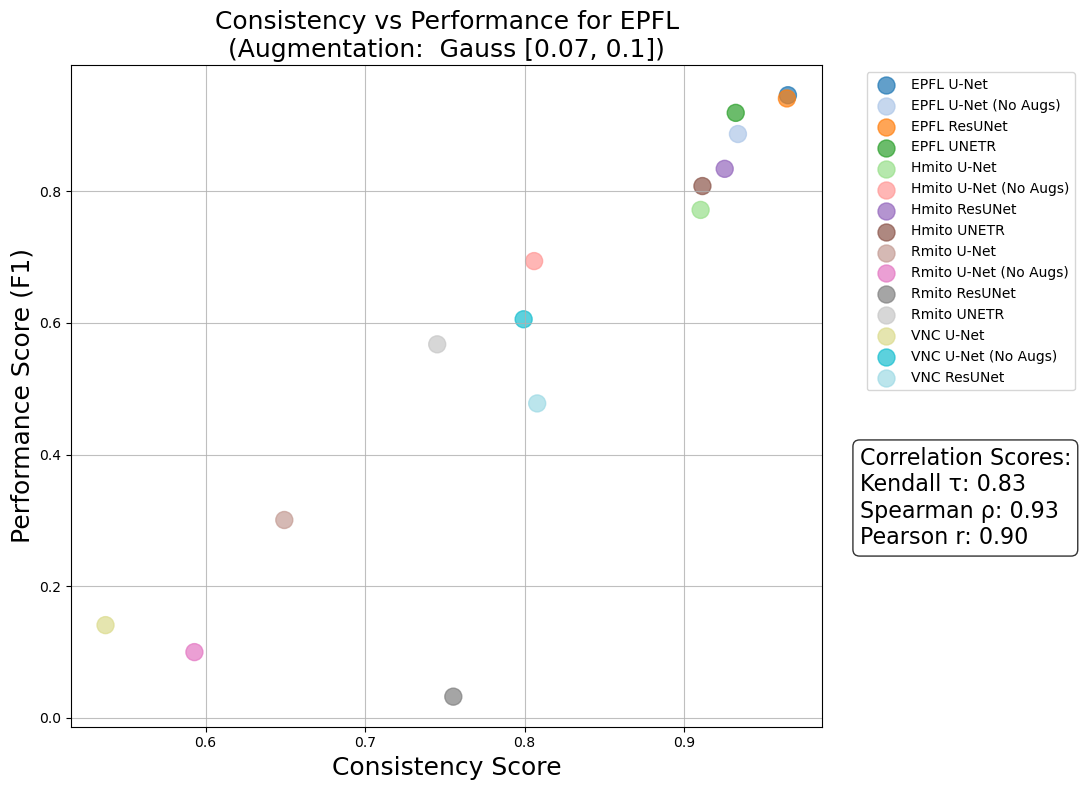

In [7]:
custom_labels = {
    "E_model_NA2": "EPFL U-Net (No Augs)",
    "E_model_Res1": "EPFL ResUNet",
    "E_model5": "EPFL U-Net",
    "E_model_Unetr2": "EPFL UNETR",
    "Hm_model_NA2": "Hmito U-Net (No Augs)",
    "Hm_model4": "Hmito U-Net",
    "Hm_model_Res1": "Hmito ResUNet", 
    "Hm_model_Unetr2": "Hmito UNETR",
    "Rm_model_NA2": "Rmito U-Net (No Augs)",
    "Rm_model4": "Rmito U-Net",
    "Rm_model_Res1": "Rmito ResUNet",
    "Rm_model_Unetr2": "Rmito UNETR",
    "V_model_NA2": "VNC U-Net (No Augs)",
    "V_model2": "VNC U-Net",
    "V_model_Res1": "VNC ResUNet"
}

# Example 1: Basic usage with default model names
fig, ax = plot_single_consistency_vs_performance(
    augmentation_strength="a007-a01",
    target_dataset="EPFL",
    performance_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/direct/EI_consistency/CMB/transfer_performance_F1_scores.json",
    base_consistency_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/direct/EI_consistency/CMB",
    custom_legend_labels=custom_labels,
    fontsize=18,
    figsize=(11, 8),
    marker_size=150,
)
plt.show()

Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/direct/EI_consistency/CMB/transfer_Gauss_a007-a01_CMB_05f_05b_EI_scores.json
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/direct/EI_consistency/CMB/transfer_performance_F1_scores.json


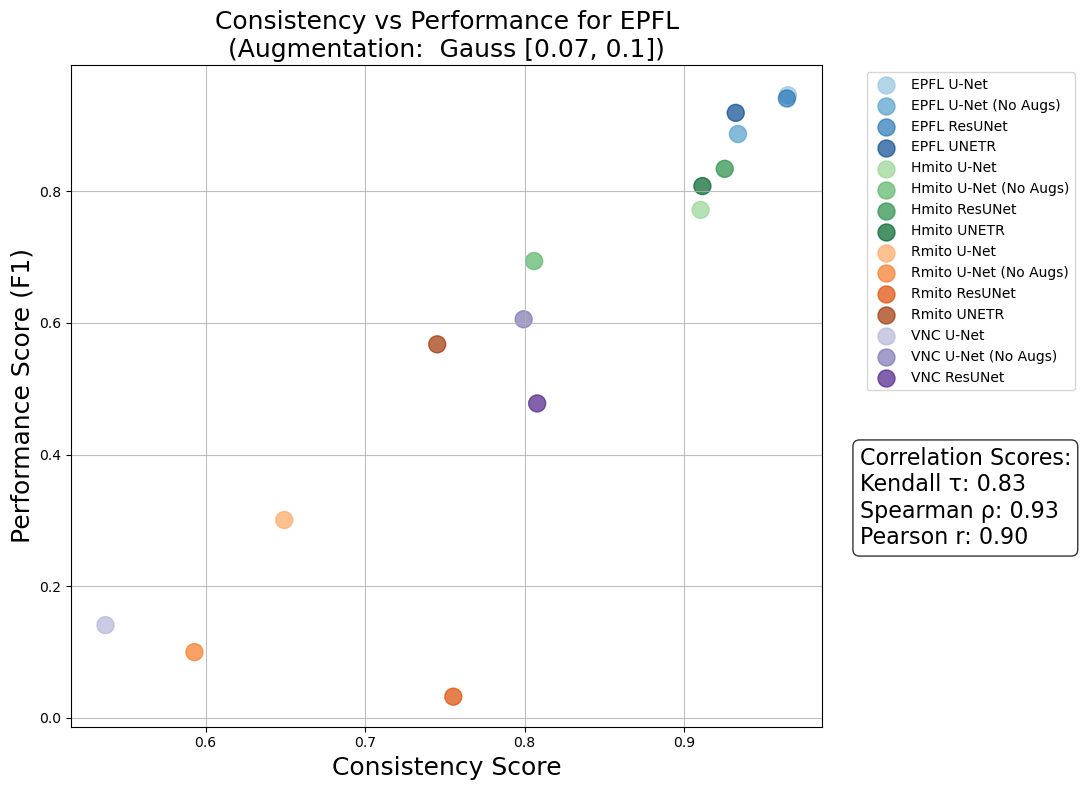

In [8]:
custom_labels = {
    "E_model_NA2": "EPFL U-Net (No Augs)",
    "E_model_Res1": "EPFL ResUNet",
    "E_model5": "EPFL U-Net",
    "E_model_Unetr2": "EPFL UNETR",
    "Hm_model_NA2": "Hmito U-Net (No Augs)",
    "Hm_model4": "Hmito U-Net",
    "Hm_model_Res1": "Hmito ResUNet", 
    "Hm_model_Unetr2": "Hmito UNETR",
    "Rm_model_NA2": "Rmito U-Net (No Augs)",
    "Rm_model4": "Rmito U-Net",
    "Rm_model_Res1": "Rmito ResUNet",
    "Rm_model_Unetr2": "Rmito UNETR",
    "V_model_NA2": "VNC U-Net (No Augs)",
    "V_model2": "VNC U-Net",
    "V_model_Res1": "VNC ResUNet"
}

# Example 1: Basic usage with default model names
fig, ax = plot_single_consistency_vs_performance2(
    augmentation_strength="a007-a01",
    target_dataset="EPFL",
    performance_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/direct/EI_consistency/CMB/transfer_performance_F1_scores.json",
    base_consistency_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/direct/EI_consistency/CMB",
    custom_legend_labels=custom_labels,
    fontsize=18,
    figsize=(11, 8),
    marker_size=150,
)
plt.show()